In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

txt_path = "./../Multi-TPC/Data/Mocap/01-28-2022/Session_1_PC_1_mocap_data.txt"  # ここを変更

# タブ区切りで読み込み
df = pd.read_csv(txt_path, sep=" ", header=None)

print(df.shape)
df.head()

(19377, 66)


,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,0.901687,9.02708,-178.042,0.134515,16.6479,18.5935,0,-2.25084,0,-1.70363,...,0,662.769,275.457,990.037,-25.7762,7.34422,177.094,56.7666,23.5891,306.904
1,0.905766,9.02697,-178.054,0.140246,16.6447,18.6032,0,-2.25567,0,-1.70292,...,0,662.856,275.546,990.034,-25.7292,7.31474,177.083,56.7710,23.5933,306.895
2,0.903228,9.02722,-178.059,0.138027,16.6459,18.6089,0,-2.26525,0,-1.69960,...,0,662.911,275.606,990.033,-25.7103,7.35034,177.070,56.8182,23.5674,306.879
3,0.902989,9.02765,-178.069,0.139048,16.6437,18.6139,0,-2.26665,0,-1.69512,...,0,662.991,275.683,990.034,-25.7479,7.35853,177.064,56.8574,23.5855,306.869
4,0.901885,9.03091,-178.074,0.141111,16.6420,18.6157,0,-2.26875,0,-1.69293,...,0,663.076,275.754,990.044,-25.7644,7.36172,177.065,56.8304,23.6048,306.874


まずは１フレーム可視化

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

txt_path = "./../Multi-TPC/Data/Mocap/01-28-2022/Session_1_PC_1_mocap_data.txt"

# タブ区切りで読み込み
df = pd.read_csv(txt_path, sep=" ", header=None)

print(df.shape)

# 1フレーム目
frame = df.iloc[0].values.astype(float)

print(frame.shape)
print(frame[:10])  # 最初の10要素だけ確認

(19377, 66)
(66,)
[ 9.01687e-01  9.02708e+00 -1.78042e+02  1.34515e-01  1.66479e+01
  1.85935e+01  0.00000e+00 -2.25084e+00  0.00000e+00 -1.70363e+00]


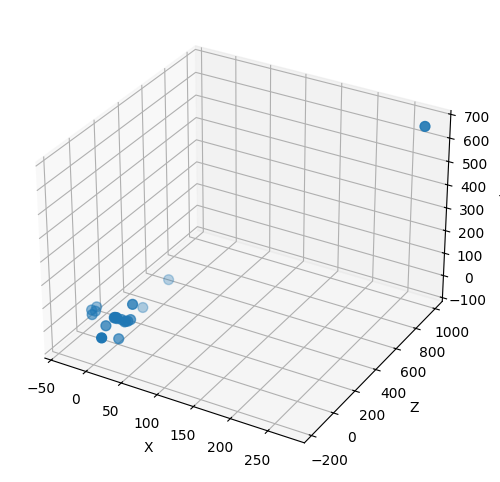

In [9]:
coords = frame.reshape(-1, 3)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(coords[:,1], coords[:,2], coords[:,0], s=50)

ax.set_xlabel("X")
ax.set_ylabel("Z")
ax.set_zlabel("Y")

plt.show()

先頭９次元を見る

(19377, 66)


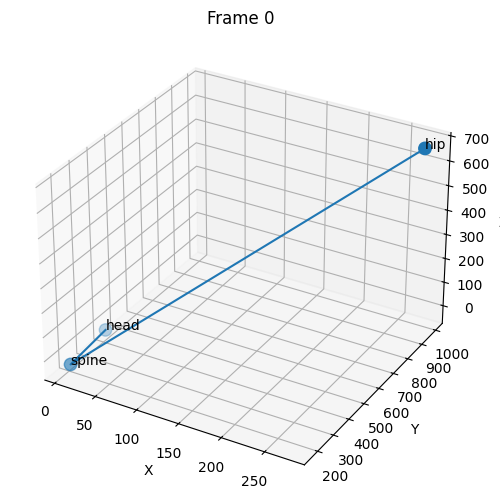

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

txt_path = "./../Multi-TPC/Data/Mocap/01-28-2022/Session_1_PC_1_mocap_data.txt"

df = pd.read_csv(txt_path, sep=r"\s+", header=None)
print(df.shape)

frame_id = 0
frame = df.iloc[frame_id].values.astype(float)

data = frame.reshape(22, 3)

# C++コードに合わせて (x,y,z) -> (y,z,x) に変換
hip   = np.array([data[19, 1], data[19, 2], data[19, 0]])
spine = np.array([data[20, 1], data[20, 2], data[20, 0]])
head  = np.array([data[21, 1], data[21, 2], data[21, 0]])

points = np.stack([hip, spine, head])
names = ["hip", "spine", "head"]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=80)
ax.plot(points[:, 0], points[:, 1], points[:, 2])

for name, p in zip(names, points):
    ax.text(p[0], p[1], p[2], name)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Frame {frame_id}")

plt.show()